#NAME :- RAHUL RAGHUNATH GONDHALI
#ROLL NO :- 25M1882

Simulating for matrix size of 100 x 100 with time step of 0.01 seconds
Final surface temperature (center of face): 1179.4 °C
Final corner temperature: 963.7 °C
Final shell thickness at the end of caster is 6.566 mm
----------------------------------------
[[ 963.66  993.83 1022.67 ... 1022.67  993.83  963.66]
 [ 993.83 1024.66 1054.18 ... 1054.18 1024.66  993.83]
 [1022.67 1054.18 1084.45 ... 1084.45 1054.18 1022.67]
 ...
 [1022.67 1054.18 1084.45 ... 1084.45 1054.18 1022.67]
 [ 993.83 1024.66 1054.18 ... 1054.18 1024.66  993.83]
 [ 963.66  993.83 1022.67 ... 1022.67  993.83  963.66]]


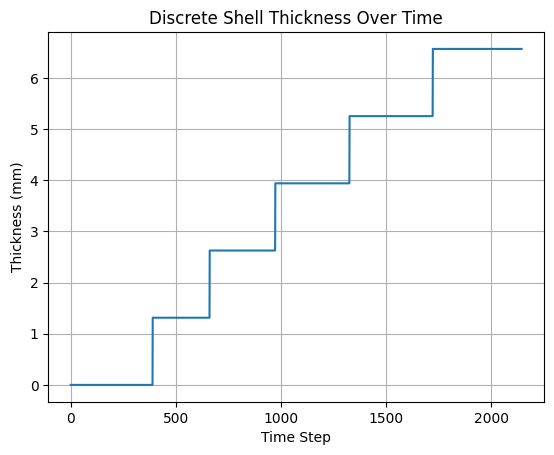

In [ ]:
# =============================================================================
# 1. LIBRARY IMPORTS
# =============================================================================
import numpy as np
import math
import matplotlib.pyplot as plt
import time

# =============================================================================
# 2. INITIALIZATION & PARAMETERS (From Problem Statement)
# =============================================================================
mould_length = 830.0            # in mm
meniscus_depth = 115.0          # in mm
billet_size = 130.0             # in mm
rho = 7.6 / 1000                # in g/cm3 / 1000
carbon_content = 0.42           # in weight %
casting_speed = 2.0 / 60        # in m/min
superheat = 30                  # Degrees
BUMPF = 7

# Grid Setup (Using 100x100)
Node_hor = 100                  # nodes in horizontal directions
Node_ver = 100                  # nodes in vertical directions
delx = (billet_size) / (Node_hor - 1)          # in mm
dely = (billet_size) / (Node_ver - 1)          # in mm
dt = 0.01                                      # Timestep in second
total_time =  ((mould_length - meniscus_depth) / 1000) / casting_speed
timestep_total = int(total_time / dt)

# Pouring temperature calculation
if carbon_content < 0.1:
    T_sol = 1534.0 - 410.0 * carbon_content
elif 0.1 <= carbon_content < 0.18:
    T_sol = 1493.0
else:
    T_sol = 1527.0 - 189.07 * carbon_content

if carbon_content < 0.51:
    T_liq = 1534.0 - 80.39 * carbon_content
else:
    T_liq = 1540.82 - 93.77 * carbon_content

T_pour = T_liq + superheat                     # Pouring temperature
T_air = 30.0
T_airl = T_airr = T_airt = T_airb = 30.0

# =============================================================================
# 3. INITIALIZATION OF ARRAYS
# =============================================================================

theta_old = np.full((Node_ver, Node_hor), float(T_pour))
Tstar = np.zeros((Node_ver, Node_hor))
K = np.zeros((Node_ver, Node_hor))
Cp = np.zeros((Node_ver, Node_hor))

SUBDAG = np.zeros(Node_hor*Node_ver - 1)
DAG = np.zeros(Node_hor*Node_ver)
SUPDAG = np.zeros(Node_hor*Node_ver - 1)
D = np.zeros(Node_hor*Node_ver)

thickenss_time = np.zeros(timestep_total)
thickenss_time_int = np.zeros(timestep_total)
mid_row = Node_ver // 2

# 10% Corner surface nodes boundaries
margin_hor = max(1, int(0.10 * Node_hor))
margin_ver = max(1, int(0.10 * Node_ver))

h_top = np.zeros(Node_hor)
h_bottom = np.zeros(Node_hor)
h_left = np.zeros(Node_ver)
h_right = np.zeros(Node_ver)


# =============================================================================
# 4. TIME LOOP
# =============================================================================
for t_idx in range(timestep_total):
    time_curr = t_idx * dt
    # Max conditional to avoid math.sqrt(0) domain errors implicitly
    t_val = time_curr #if time_curr > 0.0 else 0.001
    Q_flux = (2680.0 - (335.0 * math.sqrt(t_val))) / 1000.0
    h_effective = Q_flux / (theta_old[0, Node_hor//2] - 30.0)
    h_corner = 0.7 * h_effective

    # Apply boundary h matrices
    for j in range(Node_hor):
        if j < margin_hor or j >= Node_hor - margin_hor:
            h_top[j] = h_corner
            h_bottom[j] = h_corner
        else:
            h_top[j] = h_effective
            h_bottom[j] = h_effective

    for i in range(Node_ver):
        if i < margin_ver or i >= Node_ver - margin_ver:
            h_left[i] = h_corner
            h_right[i] = h_corner
        else:
            h_left[i] = h_effective
            h_right[i] = h_effective

    # Update Thermodynamic Properties
    for i in range(Node_ver):
        for j in range(Node_hor):
            temp = theta_old[i, j]
            # Thermal Conductivity K matrix
            if temp < 801.0:
                K[i,j] = 59.4 - 0.0418 * temp
            elif temp < T_sol:
                K[i,j] = 18.4 + 0.0094 * temp
            elif temp < T_liq:
                thk_sol = 18.4 + 0.0094 * T_sol
                K[i,j] = thk_sol + (43.0 - thk_sol) * (temp - T_sol) / (T_liq - T_sol)
            else:
                K[i,j] = 43.0 * BUMPF
            K[i,j] = (K[i,j] / 1000)      # Convert K from W/(m*K) to W/(mm*K)

            # Specific Heat Cp matrix
            if temp < 114.3: Cp[i,j] = 0.49897
            elif temp < 491.4:
                Cp[i,j] = 0.456 + 2.0 * 0.000188 * temp
            elif temp < 697.1:
                Cp[i,j] = 0.268 + 2.0 * 0.000418 * temp
            elif temp < 742.9:
                Cp[i,j] = 1.431
            elif temp < 868.6:
                Cp[i,j] = 3.849 - 2.0 * 0.001883 * temp
            elif temp < 1142.9:
                Cp[i,j] = 0.648
            elif temp < T_sol:
                Cp[i,j] = 0.268 + 2.0 * 0.000167 * temp
            elif temp < T_liq:
                Cp[i,j] = (0.268 + 2.0 * 0.000167 * temp) + 272.0 / (T_liq - T_sol)
            else:
                Cp[i,j] = 0.787

# =========================================================================
# 5. PASS 1: VERTICAL IMPLICIT
# =========================================================================
    SUBDAG[:] = 0.0
    DAG[:] = 0.0
    SUPDAG[:] = 0.0
    D[:] = 0.0

    # 1. Top-left corner node
    i, j = 0, 0
    Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
    Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
    DAG[0] = -(h_top[j]*dt)/(rho*Cp[i, j]*dely) - (Kb*dt)/(rho*Cp[i, j]*dely**2) - 1
    SUPDAG[0] = (Kb*dt)/(rho*Cp[i, j]*dely**2)
    D[0] = ((h_left[i]*dt)/(rho*Cp[i, j]*delx) + (Kr*dt)/(rho*Cp[i, j]*delx**2) -1)*theta_old[i, j] - ((Kr*dt)/(rho*Cp[i, j]*delx**2))*theta_old[i,j+1] - ((h_top[j]*dt)/(rho*Cp[i, j]*dely))*T_airt - ((h_left[i]*dt)/(rho*Cp[i, j]*delx))*T_airl

    # 2. Top-Right corner node
    i, j = 0, Node_hor - 1
    k_idx = j*Node_ver + i
    Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
    Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
    DAG[k_idx] = -(h_top[j]*dt)/(rho*Cp[i, j]*dely)-(Kb*dt)/(rho*Cp[i, j]*dely**2)-1
    SUPDAG[k_idx] = (Kb*dt)/(rho*Cp[i, j]*dely**2)
    D[k_idx] = ((h_right[i]*dt)/(rho*Cp[i, j]*delx)+(Kl*dt)/(rho*Cp[i, j]*delx**2)-1)*theta_old[i,j] - ((Kl*dt)/(rho*Cp[i, j]*delx**2))*theta_old[i,j-1] - ((h_right[i]*dt)/(rho*Cp[i, j]*delx))*T_airr - ((h_top[j]*dt)/(rho*Cp[i, j]*dely))*T_airt

    # 3. Bottom-left corner node
    i, j = Node_ver - 1, 0
    k_idx = j*Node_ver + i
    Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
    Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
    SUBDAG[k_idx-1] = (Kt*dt)/(rho*Cp[i, j]*dely**2)
    DAG[k_idx] = -(h_bottom[j]*dt)/(rho*Cp[i, j]*dely) - (Kt*dt)/(rho*Cp[i, j]*dely**2) - 1
    D[k_idx] = ((h_left[i]*dt)/(rho*Cp[i, j]*delx) + (Kr*dt)/(rho*Cp[i, j]*delx**2) - 1)*theta_old[i,j] - ((Kr*dt)/(rho*Cp[i, j]*delx**2))*theta_old[i,j+1] - ((h_left[i]*dt)/(rho*Cp[i, j]*delx))*T_airl - ((h_bottom[j]*dt)/(rho*Cp[i, j]*dely))*T_airb

    # 4. Bottom-Right corner node
    i, j = Node_ver-1, Node_hor-1
    k_idx = j*Node_ver + i
    Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
    Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
    SUBDAG[k_idx-1] = (Kt*dt)/(rho*Cp[i, j]*dely**2)
    DAG[k_idx] = -(h_bottom[j]*dt)/(rho*Cp[i, j]*dely) - (Kt*dt)/(rho*Cp[i, j]*dely**2) - 1
    D[k_idx] = ((h_right[i]*dt)/(rho*Cp[i, j]*delx)+(Kl*dt)/(rho*Cp[i, j]*delx**2)-1)*theta_old[i,j] - ((Kl*dt)/(rho*Cp[i, j]*delx**2))*theta_old[i,j-1] - ((h_right[i]*dt)/(rho*Cp[i, j]*delx))*T_airr - ((h_bottom[j]*dt)/(rho*Cp[i, j]*dely))*T_airb

    # 5. Left surface node
    j = 0
    for i in range(1, Node_ver-1):
        k_idx = j*Node_ver + i
        Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
        Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
        Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
        SUBDAG[k_idx-1] = (Kt*dt)/(2*rho*Cp[i, j]*dely**2)
        DAG[k_idx] = -(Kt*dt)/(2*rho*Cp[i, j]*dely**2) - (Kb*dt)/(2*rho*Cp[i, j]*dely**2) - 1
        SUPDAG[k_idx] = (Kb*dt)/(2*rho*Cp[i, j]*dely**2)
        D[k_idx] = ((h_left[i]*dt)/(rho*Cp[i,j]*delx) + (Kr*dt)/(rho*Cp[i,j]*delx**2) - 1)*theta_old[i,j] - ((Kr*dt)/(rho*Cp[i,j]*delx**2))*theta_old[i,j+1] - ((h_left[i]*dt)/(rho*Cp[i,j]*delx))*T_airl

    # 6. Top surface node
    i = 0
    for j in range(1, Node_hor-1):
        k_idx = j*Node_ver + i
        Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
        Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
        Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
        DAG[k_idx] = -(h_top[j]*dt)/(rho*Cp[i, j]*dely)-(Kb*dt)/(rho*Cp[i, j]*dely**2)-1
        SUPDAG[k_idx] = (Kb*dt)/(rho*Cp[i, j]*dely**2)
        D[k_idx] = ((Kl*dt)/(2*rho*Cp[i, j]*delx**2)+(Kr*dt)/(2*rho*Cp[i, j]*delx**2)-1)*theta_old[i,j] - ((Kl*dt)/(2*rho*Cp[i,j]*delx**2))*theta_old[i,j-1]  - ((Kr*dt)/(2*rho*Cp[i,j]*delx**2))*theta_old[i,j+1] - ((h_top[j]*dt)/(rho*Cp[i,j]*dely))*T_airt

    # 7. Right surface node
    j = Node_hor-1
    for i in range(1, Node_ver-1):
        k_idx = j*Node_ver + i
        Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
        Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
        Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
        SUBDAG[k_idx-1] = (Kt*dt)/(2*rho*Cp[i, j]*dely**2)
        DAG[k_idx] = -(Kb*dt)/(2*rho*Cp[i, j]*dely**2)-(Kt*dt)/(2*rho*Cp[i, j]*dely**2)-1
        SUPDAG[k_idx] = (Kb*dt)/(2*rho*Cp[i, j]*dely**2)
        D[k_idx] = ((h_right[i]*dt)/(rho*Cp[i,j]*delx) + (Kl*dt)/(rho*Cp[i,j]*delx**2) - 1)*theta_old[i,j] - ((Kl*dt)/(rho*Cp[i,j]*delx**2))*theta_old[i,j-1] - ((h_right[i]*dt)/(rho*Cp[i,j]*delx))*T_airr

    # 8. Bottom surface node
    i = Node_ver-1
    for j in range(1, Node_hor-1):
        k_idx = j*Node_ver + i
        Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
        Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
        Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
        SUBDAG[k_idx-1] = (Kt*dt)/(rho*Cp[i, j]*dely**2)
        DAG[k_idx] = -(Kt*dt)/(rho*Cp[i, j]*dely**2)-(h_bottom[j]*dt)/(rho*Cp[i, j]*dely)-1
        D[k_idx] = ((Kl*dt)/(2*rho*Cp[i, j]*delx**2)+(Kr*dt)/(2*rho*Cp[i, j]*delx**2)-1)*theta_old[i,j] - ((Kl*dt)/(2*rho*Cp[i, j]*delx**2))*theta_old[i,j-1] - ((Kr*dt)/(2*rho*Cp[i, j]*delx**2))*theta_old[i,j+1] - ((h_bottom[j]*dt)/(rho*Cp[i, j]*dely))*T_airb

    # 9. Internal node
    for i in range(1, Node_ver-1):
        for j in range(1, Node_hor-1):
            k_idx = j*Node_ver + i
            Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
            Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
            Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
            Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
            SUBDAG[k_idx-1]  =  (Kt*dt)/(2*rho*Cp[i, j]*dely**2)
            DAG[k_idx] = -(Kt*dt)/(2*rho*Cp[i, j]*dely**2)-(Kb*dt)/(2*rho*Cp[i, j]*dely**2)-1
            SUPDAG[k_idx] = (Kb*dt)/(2*rho*Cp[i, j]*dely**2)
            D[k_idx] = ((Kl*dt)/(2*rho*Cp[i, j]*delx**2)+(Kr*dt)/(2*rho*Cp[i, j]*delx**2)-1)*theta_old[i,j] - ((Kl*dt)/(2*rho*Cp[i, j]*delx**2))*theta_old[i,j-1] - ((Kr*dt)/(2*rho*Cp[i, j]*delx**2))*theta_old[i,j+1]

    # --- TDMA Solver for Vertical ---
    for m in range(1, Node_hor*Node_ver):
        factor = SUBDAG[m - 1] / DAG[m - 1]
        DAG[m] -= factor * SUPDAG[m - 1]
        D[m] -= factor * D[m - 1]
    D[-1] = D[-1] / DAG[-1]
    for m in range(Node_hor*Node_ver - 2, -1, -1):
        D[m] = (D[m] - SUPDAG[m] * D[m + 1]) / DAG[m]

# =============================================================================
# 6. WRITES I
# =============================================================================
    for j in range(0, Node_hor):
        for i in range(0, Node_ver):
            Tstar[i,j] = D[i*Node_hor + j]

# =========================================================================
# 7. PASS 2: HORIZONTAL IMPLICIT
# =========================================================================
    SUBDAG[:] = 0.0
    DAG[:] = 0.0
    SUPDAG[:] = 0.0
    D[:] = 0.0

    # 1. Top-left corner node
    i, j = 0, 0
    Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
    Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
    DAG[0] = -(h_left[i]*dt)/(rho*Cp[i, j]*delx) - (Kr*dt)/(rho*Cp[i, j]*delx**2) - 1
    SUPDAG[0] = (Kr*dt)/(rho*Cp[i, j]*delx**2)
    D[0] = ((h_top[j]*dt)/(rho*Cp[i, j]*dely) + (Kb*dt)/(rho*Cp[i, j]*dely**2) -1)*Tstar[i, j] - ((Kb*dt)/(rho*Cp[i, j]*dely**2))*Tstar[i+1, j] - ((h_left[i]*dt)/(rho*Cp[i, j]*delx))*T_airl - ((h_top[j]*dt)/(rho*Cp[i, j]*dely))*T_airt

    # 2. Top-Right corner node
    i, j = 0, Node_hor - 1
    H = i*Node_hor + j
    Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
    Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
    SUBDAG[H-1] = (Kl*dt)/(rho*Cp[i, j]*delx**2)
    DAG[H] = -(Kl*dt)/(rho*Cp[i, j]*delx**2)-(h_right[i]*dt)/(rho*Cp[i, j]*delx)-1
    D[H] = ((h_top[j]*dt)/(rho*Cp[i, j]*dely)+(Kb*dt)/(rho*Cp[i, j]*dely**2)-1)*Tstar[i,j] - ((Kb*dt)/(rho*Cp[i, j]*dely**2))*Tstar[i+1,j] - ((h_right[i]*dt)/(rho*Cp[i, j]*delx))*T_airr - ((h_top[j]*dt)/(rho*Cp[i, j]*dely))*T_airt

    # 3. Bottom-left corner node
    i, j = Node_ver - 1, 0
    H = i*Node_hor + j
    Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
    Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
    DAG[H] = -(h_left[i]*dt)/(rho*Cp[i, j]*delx) - (Kr*dt)/(rho*Cp[i, j]*delx**2) - 1
    SUPDAG[H] = (Kr*dt)/(rho*Cp[i, j]*delx**2)
    D[H] = ((Kt*dt)/(rho*Cp[i, j]*dely**2) + (h_bottom[j]*dt)/(rho*Cp[i, j]*dely) - 1)*Tstar[i,j] - ((Kt*dt)/(rho*Cp[i, j]*dely**2))*Tstar[i-1,j] - ((h_left[i]*dt)/(rho*Cp[i, j]*delx))*T_airl - ((h_bottom[j]*dt)/(rho*Cp[i, j]*dely))*T_airb

    # 4. Bottom-Right corner node
    i, j = Node_ver-1, Node_hor-1
    H = i*Node_hor + j
    Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
    Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
    SUBDAG[H-1] = (Kl*dt)/(rho*Cp[i, j]*delx**2)
    DAG[H] = -(Kl*dt)/(rho*Cp[i, j]*delx**2)-(h_right[i]*dt)/(rho*Cp[i, j]*delx)-1
    D[H] = ((h_bottom[j]*dt)/(rho*Cp[i, j]*dely)+(Kt*dt)/(rho*Cp[i, j]*dely**2)-1)*Tstar[i,j] - ((Kt*dt)/(rho*Cp[i, j]*dely**2))*Tstar[i-1,j] - ((h_right[i]*dt)/(rho*Cp[i, j]*delx))*T_airr - ((h_bottom[j]*dt)/(rho*Cp[i, j]*dely))*T_airb

    # 5. Left surface node
    j = 0
    for i in range(1, Node_ver-1):
        H = i*Node_hor + j
        Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
        Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
        Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
        DAG[H] = -(h_left[i]*dt)/(rho*Cp[i, j]*delx) - (Kr*dt)/(rho*Cp[i, j]*delx**2) - 1
        SUPDAG[H] = (Kr*dt)/(rho*Cp[i, j]*delx**2)
        D[H] = ((Kt*dt)/(2*rho*Cp[i,j]*dely**2) + (Kb*dt)/(2*rho*Cp[i,j]*dely**2) - 1)*Tstar[i,j] - ((Kt*dt)/(2*rho*Cp[i,j]*dely**2))*Tstar[i-1,j] - ((h_left[i]*dt)/(rho*Cp[i,j]*delx))*T_airl - ((Kb*dt)/(2*rho*Cp[i,j]*dely**2))*Tstar[i+1,j]

    # 6. Top surface node
    i = 0
    for j in range(1, Node_hor-1):
        H = i*Node_hor + j
        Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
        Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
        Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
        SUBDAG[H-1] = (Kl*dt)/(2*rho*Cp[i, j]*delx**2)
        DAG[H] = -(Kl*dt)/(2*rho*Cp[i, j]*delx**2)-(Kr*dt)/(2*rho*Cp[i, j]*delx**2)-1
        SUPDAG[H] = (Kr*dt)/(2*rho*Cp[i, j]*delx**2)
        D[H] = ((h_top[j]*dt)/(rho*Cp[i, j]*dely)+(Kb*dt)/(rho*Cp[i, j]*dely**2)-1)*Tstar[i,j] - ((Kb*dt)/(rho*Cp[i, j]*dely**2))*Tstar[i+1,j] - ((h_top[j]*dt)/(rho*Cp[i, j]*dely))*T_airt

    # 7. Right surface node
    j = Node_hor-1
    for i in range(1, Node_ver-1):
        H = i*Node_hor + j
        Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
        Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
        Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
        SUBDAG[H-1] = (Kl*dt)/(rho*Cp[i, j]*delx**2)
        DAG[H] = -(Kl*dt)/(rho*Cp[i, j]*delx**2)-(h_right[i]*dt)/(rho*Cp[i, j]*delx)-1
        D[H] = ((Kt*dt)/(2*rho*Cp[i,j]*dely**2) + (Kb*dt)/(2*rho*Cp[i,j]*dely**2) - 1)*Tstar[i,j] - ((Kt*dt)/(2*rho*Cp[i,j]*dely**2))*Tstar[i-1,j] - ((h_right[i]*dt)/(rho*Cp[i,j]*delx))*T_airr - ((Kb*dt)/(2*rho*Cp[i,j]*dely**2))*Tstar[i+1,j]

    # 8. Bottom surface node
    i = Node_ver-1
    for j in range(1, Node_hor-1):
        H = i*Node_hor + j
        Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
        Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
        Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
        SUBDAG[H-1] = (Kl*dt)/(2*rho*Cp[i, j]*delx**2)
        DAG[H] = -(Kl*dt)/(2*rho*Cp[i, j]*delx**2)-(Kr*dt)/(2*rho*Cp[i, j]*delx**2)-1
        SUPDAG[H] = (Kr*dt)/(2*rho*Cp[i, j]*delx**2)
        D[H] = ((h_bottom[j]*dt)/(rho*Cp[i, j]*dely)+(Kt*dt)/(rho*Cp[i, j]*dely**2)-1)*Tstar[i,j] - ((Kt*dt)/(rho*Cp[i, j]*dely**2))*Tstar[i-1,j] - ((h_bottom[j]*dt)/(rho*Cp[i, j]*dely))*T_airb

    # 9. Internal node
    for i in range(1, Node_ver-1):
        for j in range(1, Node_hor-1):
            H = i*Node_hor + j
            Kl = (2 * K[i, j-1] * K[i, j]) / (K[i, j-1] + K[i, j])
            Kr = (2 * K[i, j+1] * K[i, j]) / (K[i, j+1] + K[i, j])
            Kb = (2 * K[i+1, j] * K[i, j]) / (K[i+1, j] + K[i, j])
            Kt = (2 * K[i-1, j] * K[i, j]) / (K[i-1, j] + K[i, j])
            SUBDAG[H-1]  =  (Kl*dt)/(2*rho*Cp[i, j]*delx**2)
            DAG[H] = -(Kl*dt)/(2*rho*Cp[i, j]*delx**2)-(Kr*dt)/(2*rho*Cp[i, j]*delx**2)-1
            SUPDAG[H] = (Kr*dt)/(2*rho*Cp[i, j]*delx**2)
            D[H] = ((Kt*dt)/(2*rho*Cp[i, j]*dely**2)+(Kb*dt)/(2*rho*Cp[i, j]*dely**2)-1)*Tstar[i,j] - ((Kt*dt)/(2*rho*Cp[i, j]*dely**2))*Tstar[i-1,j] - ((Kb*dt)/(2*rho*Cp[i, j]*dely**2))*Tstar[i+1,j]

    # --- TDMA Solver for Horizontal ---
    for k in range(1, Node_hor*Node_ver):
        factor = SUBDAG[k-1] / DAG[k - 1]
        DAG[k] -= factor * SUPDAG[k - 1]
        D[k] -= factor * D[k - 1]
    D[-1] = D[-1] / DAG[-1]
    for m in range(Node_hor*Node_ver - 2, -1, -1):
        D[m] = (D[m] - SUPDAG[m] * D[m + 1]) / DAG[m]

# =============================================================================
# 8. WRITES II
# =============================================================================
    for i in range(0, Node_ver):
        for j in range(0, Node_hor):
            theta_old[i,j] = D[i*Node_hor + j]

# =========================================================================
# 9. PLOT DATA EXTRACTION (Inside Loop)
# =========================================================================
    discrete_thickness = 0.0
    interpolated_thickness = 0.0
    for j in range(Node_hor // 2):
        T_current = theta_old[mid_row, j]
        T_next = theta_old[mid_row, j+1]

        # If current node is solid, but the next one is mushy/liquid
        if T_current < T_sol and T_next >= T_sol:
            # Strictly use the coordinate of the last solid node
            discrete_thickness = j * delx
            thickenss_time[t_idx] = discrete_thickness
            # Linear interpolation for exact position of T_sol
            fraction = (T_sol - T_current) / (T_next - T_current)
            interpolated_thickness = (j + fraction) * delx
            thickenss_time_int[t_idx] = interpolated_thickness
            break

# =============================================================================
# 10. EXECUTE & OUTPUT
# =============================================================================
end_time = time.time()
#print(f"Simulation Complete in {end_time - start_time:.2f} seconds.")

# Print Metrics
print(f"Simulating for matrix size of {Node_hor} x {Node_ver} with time step of {dt} seconds")
print(f"Final surface temperature (center of face): {theta_old[0, Node_hor//2]:.1f} °C")
print(f"Final corner temperature: {theta_old[0, 0]:.1f} °C")
print(f"Final shell thickness at the end of caster is {thickenss_time[-1]:.3f} mm")
print("-" * 40)
print(np.round(theta_old, 2))

# Plot
plt.plot(np.linspace(0, len(thickenss_time), timestep_total), thickenss_time)
plt.title("Discrete Shell Thickness Over Time")
plt.xlabel("Time Step")
plt.ylabel("Thickness (mm)")
plt.grid(True)
plt.show()

In [ ]:
discrete_thickness = 0.0
interpolated_thickness = 0.0
last_node = 0
next_node = 0

thickenss_time = np.zeros(timestep_total)
thickenss_time_int = np.zeros(timestep_total)
mid_row = Node_ver // 2
for t_idx in range(timestep_total):

    for j in range(Node_hor // 2):
        T_current = theta_old[mid_row, j]
        T_next = theta_old[mid_row, j+1]

        # If current node is solid, but the next one is mushy/liquid
        if T_current < T_sol and T_next >= T_sol:
            # Strictly use the coordinate of the last solid node
            discrete_thickness = j * delx
            thickenss_time[t_idx] = discrete_thickness
            # Linear interpolation for exact position of T_sol
            fraction = (T_sol - T_current) / (T_next - T_current)
            interpolated_thickness = (j + fraction) * delx
            thickenss_time_int[t_idx] = interpolated_thickness
            last_node = T_current
            next_node = T_next
            break
print(f"Corner node temp - {theta_old[0, 0]:.2f} °C")
print(f"Surface node temp - {theta_old[0, Node_hor//2]:.2f} °C")
print(f"Centre node temp - {theta_old[Node_hor//2, Node_ver//2]:.2f} °C")
print(f"Shell Thickness - {thickenss_time[-1]:.2f} mm")
# print(T_sol)
# print(T_liq)
print(f"Interpolated Shell Thickness {thickenss_time_int[-1]:.3f}")
print(f"Number of solid blocks {thickenss_time[-1]//delx}")
print(f"Last solid node temperature  - {last_node:.2f} °C")
print(f"First Unsolidified node temperature- {next_node:.2f} °C")

Corner node temp - 963.66 °C
Surface node temp - 1179.40 °C
Centre node temp - 1512.08 °C
Shell Thickness - 6.57 mm
7.842
5.0
First - 1409.20 °C
Last - 1448.71 °C
1.3131313131313131
